# APO Multi-Model Benchmark — Comprehensive Analysis

This notebook analyses automatic prompt-optimization (APO) results across three experiment directories, covering four models, five APO methods plus a hand-written baseline, six benchmark tasks, and three random seeds per configuration.

| Directory | Model(s) | Tasks | Methods |
|---|---|---|---|
| `proposal_comparison_3bench_qwen3-4-instruct` | Qwen3-4B | 4 BBH + GSM8K + HumanEval | SWIFT, APEX, CAPO, GAAPO, SEE + baseline |
| `multi_model_cot_4bs` | Llama-3.2-3B | 4 BBH tasks | SWIFT, APEX, CAPO, GAAPO, SEE |

**Sections**
1. Setup & Data Loading  
2. Data Coverage  
3. Overall Performance Summary  
4. Task-Level Method Comparison  
5. Model Comparison  
6. Optimization Gain (APO vs Baseline)  
7. Learning Curves  
8. Efficiency Analysis  
9. Operator Usage  
10. Cross-Task Ranking  
11. Statistical Summary  

## 1 — Setup & Data Loading

All three result directories share the same JSON schema (`method_name`, `dataset_name`, `test_score`, `best_score`, `llm_usage`, `optimization_history`, `config`).  
The only structural difference is the directory layout: Qwen3-4B results sit at `method/task/seed_N/`, while the multi-model directories add a model subdirectory above that.

In [3]:
import json
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='tab10', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.constrained_layout.use': True,
})

OUTPUTS = Path('../outputs')

# ── Canonical ordering ──────────────────────────────────────────────────────
METHOD_ORDER = ['baseline', 'swift', 'apex', 'capo', 'gaapo', 'see']
MODEL_ORDER  = ['Llama-3.2-3B', 'Qwen3-4B', 'Gemma-2-9B', 'DeepSeek-7B']
TASK_ORDER   = ['causal_judgement', 'disambiguation_qa', 'formal_fallacies',
                'hyperbaton', 'gsm8k', 'humaneval']
TASK_LABELS  = {'causal_judgement': 'Causal\nJudgement',
                'disambiguation_qa': 'Disambig.\nQA',
                'formal_fallacies': 'Formal\nFallacies',
                'hyperbaton': 'Hyperbaton',
                'gsm8k': 'GSM8K',
                'humaneval': 'HumanEval'}

# Map raw dir/config strings → display names
MODEL_DISPLAY = {
    'llama-3.2-3b-instruct': 'Llama-3.2-3B',
    'deepseek-coder-7b-instruct-v1.5': 'DeepSeek-7B',
    'gemma-2-9b-it': 'Gemma-2-9B',
    'meta-llama/llama-3.2-3b-instruct': 'Llama-3.2-3B',
    'deepseek-ai/deepseek-coder-7b-instruct-v1.5': 'DeepSeek-7B',
    'google/gemma-2-9b-it': 'Gemma-2-9B',
    'qwen/qwen3-4b-instruct-2507': 'Qwen3-4B',
}

# Colour palette — consistent across all charts
METHOD_PALETTE = dict(zip(METHOD_ORDER, sns.color_palette('tab10', len(METHOD_ORDER))))
MODEL_PALETTE  = dict(zip(MODEL_ORDER,  sns.color_palette('Set2',  len(MODEL_ORDER))))

In [4]:
# ── Source directories and default model name when there is no model subdir ──
SOURCES = [
    {'dir': OUTPUTS / 'proposal_comparison_3bench_qwen3-4-instruct', 'flat_model': 'Qwen3-4B'},
    {'dir': OUTPUTS / 'multi_model_cot_4bs',                         'flat_model': None},
]

rows, traj_rows = [], []

for src in SOURCES:
    base        = src['dir']
    flat_model  = src['flat_model']

    for f in sorted(base.rglob('result_*.json')):
        rel = f.relative_to(base).parts
        # Layout A (flat — Qwen3-4B):  method / task / seed_N / result_*.json  → 4 parts
        # Layout B (model subdir):     model  / method / task / seed_N / …    → 5 parts
        if len(rel) == 4:
            model_dir, method_dir, task_dir, seed_dir = flat_model, rel[0], rel[1], rel[2]
        elif len(rel) == 5:
            model_dir, method_dir, task_dir, seed_dir = rel[0], rel[1], rel[2], rel[3]
        else:
            continue

        d    = json.loads(f.read_text(encoding='utf-8'))
        cfg  = d.get('config') or {}

        # Resolve model name: prefer config string → dir name → fallback
        cfg_model = (cfg.get('model') or '').strip()
        model = (
            MODEL_DISPLAY.get(cfg_model)
            or MODEL_DISPLAY.get(cfg_model.lower())
            or MODEL_DISPLAY.get((model_dir or '').lower())
            or model_dir
            or 'Unknown'
        )

        task   = (d.get('dataset_name') or task_dir or '').replace('bbh_', '')
        method = d.get('method_name') or method_dir or ''
        seed   = cfg.get('run_seed', 0) or int((seed_dir or 'seed_0').replace('seed_', ''))

        usage = d.get('llm_usage') or {}
        rows.append({
            'model'    : model,
            'method'   : method,
            'task'     : task,
            'seed'     : seed,
            'dev'      : d.get('best_score',   0.0),
            'test'     : d.get('test_score',   0.0),
            'time_s'   : d.get('total_time',   0.0),
            'n_iters'  : d.get('num_iterations', 0),
            'calls'    : usage.get('total_calls', 0),
            'tokens_in' : usage.get('total_input_tokens', 0),
            'tokens_out': usage.get('total_output_tokens', 0),
            'tokens'   : usage.get('total_tokens', 0),
        })

        # Optimization history  (one row per operator per generation)
        for g in d.get('optimization_history', []):
            for op, cnt in (g.get('operator_counts') or {}).items():
                traj_rows.append({
                    'model': model, 'method': method, 'task': task, 'seed': seed,
                    'generation': g['generation'],
                    'best_score': g['best_score'],
                    'mean_score': g.get('mean_score', 0.0),
                    'operator': op,
                    'count': cnt,
                })

df  = pd.DataFrame(rows)
tdf = pd.DataFrame(traj_rows)

# Apply canonical ordering
for col, order in [('method', METHOD_ORDER), ('model', MODEL_ORDER), ('task', TASK_ORDER)]:
    present = [x for x in order if x in df[col].unique()]
    df[col] = pd.Categorical(df[col], categories=present, ordered=True)

df = df.sort_values(['model', 'method', 'task', 'seed']).reset_index(drop=True)

print(f'Total runs   : {len(df)}')
print(f'Models       : {df.model.cat.categories.tolist()}')
print(f'Methods      : {df.method.cat.categories.tolist()}')
print(f'Tasks        : {df.task.cat.categories.tolist()}')
df.head(3)

Total runs   : 171
Models       : ['Llama-3.2-3B', 'Qwen3-4B']
Methods      : ['baseline', 'swift', 'apex', 'capo', 'gaapo', 'see']
Tasks        : ['causal_judgement', 'disambiguation_qa', 'formal_fallacies', 'hyperbaton', 'gsm8k', 'humaneval']


,model,method,task,seed,dev,test,time_s,n_iters,calls,tokens_in,tokens_out,tokens
0,Llama-3.2-3B,swift,causal_judgement,7,0.64,0.573913,217.87,3,200,875538,13645,889183
1,Llama-3.2-3B,swift,causal_judgement,42,0.54,0.556522,181.09,3,277,690046,16038,706084
2,Llama-3.2-3B,swift,causal_judgement,123,0.62,0.565217,253.78,3,249,892780,18623,911403


## 2 — Data Coverage

Not every (model, method, task) triple has results — Gemma-2-9B and DeepSeek-7B runs were stopped early. The heatmap below shows how many seeds are recorded for each cell; the target is 3.

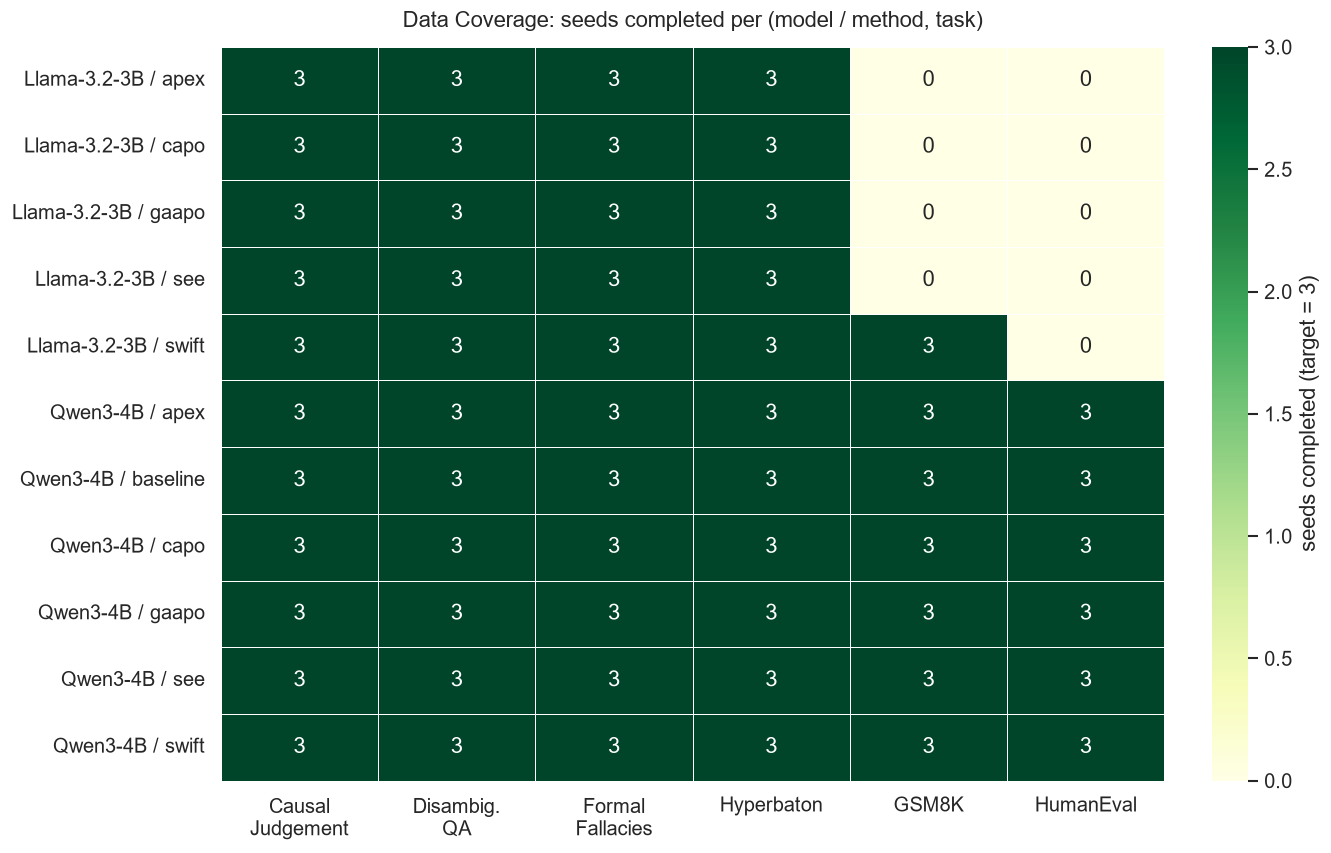

tasks  total_runs  avg_test
model        method                               
Llama-3.2-3B swift         5          15     0.592
             apex          4          12     0.529
             capo          4          12     0.554
             gaapo         4          12     0.554
             see           4          12     0.536
Qwen3-4B     baseline      6          18     0.474
             swift         6          18     0.758
             apex          6          18     0.760
             capo          6          18     0.746
             gaapo         6          18     0.761
             see           6          18     0.754

In [5]:
# Completeness heatmap — runs per (model×method, task)
counts = df.groupby(['model', 'method', 'task'], observed=True).size().reset_index(name='n_seeds')
counts['model_method'] = counts['model'].astype(str) + ' / ' + counts['method'].astype(str)

pivot = counts.pivot(index='model_method', columns='task', values='n_seeds').fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(
    pivot, annot=True, fmt='d', linewidths=0.5,
    cmap='YlGn', vmin=0, vmax=3,
    cbar_kws={'label': 'seeds completed (target = 3)'},
    ax=ax
)
ax.set_title('Data Coverage: seeds completed per (model / method, task)', fontsize=13, pad=12)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels([TASK_LABELS.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()],
                   rotation=0, ha='center')
plt.show()

# Quick summary table
summary = df.groupby(['model', 'method'], observed=True).agg(
    tasks=('task', 'nunique'),
    total_runs=('seed', 'count'),
    avg_test=('test', 'mean'),
).round(3)
summary

## 3 — Overall Performance Summary

The table below aggregates test scores (mean ± std across all available seeds for each model-method pair). Due to the unbalanced coverage, macro-averages are computed only over tasks where a model-method has at least one run.

In [6]:
overall = (
    df.groupby(['model', 'method'], observed=True)['test']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'avg_test', 'std': 'std_test', 'count': 'n_runs'})
    .round(3)
)
overall['std_test'] = overall['std_test'].fillna(0)
overall['score_fmt'] = overall.apply(lambda r: f"{r['avg_test']:.3f} ± {r['std_test']:.3f}", axis=1)
print('Macro-avg test score per (model, method) — mean ± std over all runs')
overall[['score_fmt', 'n_runs']]

Macro-avg test score per (model, method) — mean ± std over all runs


score_fmt  n_runs
model        method                         
Llama-3.2-3B swift     0.592 ± 0.119      15
             apex      0.529 ± 0.098      12
             capo      0.554 ± 0.086      12
             gaapo     0.554 ± 0.088      12
             see       0.536 ± 0.081      12
Qwen3-4B     baseline  0.474 ± 0.216      18
             swift     0.758 ± 0.141      18
             apex      0.760 ± 0.160      18
             capo      0.746 ± 0.130      18
             gaapo     0.761 ± 0.140      18
             see       0.754 ± 0.157      18

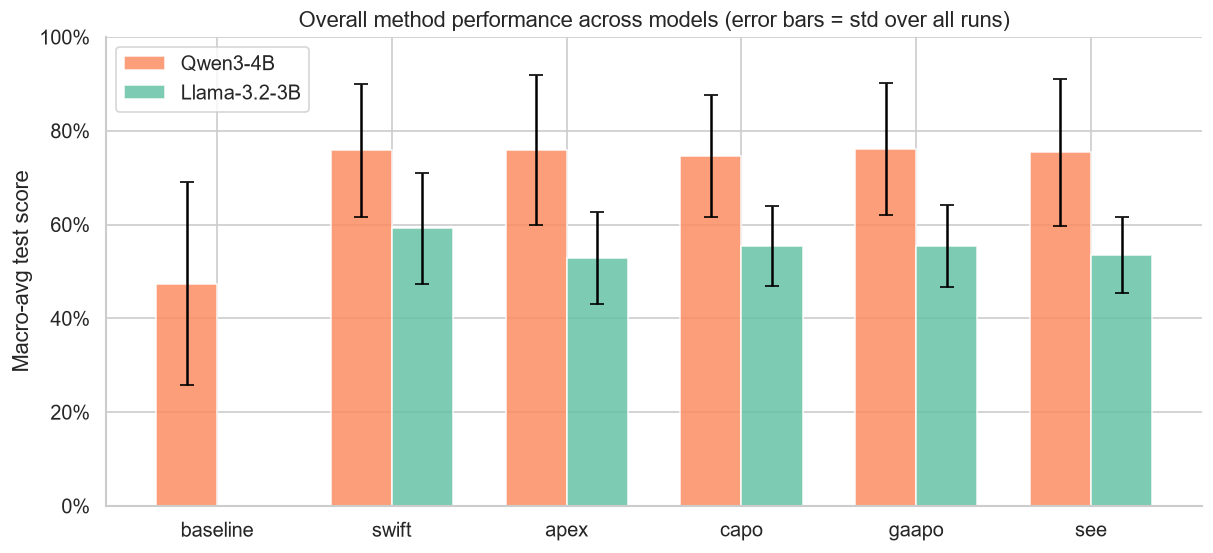

In [7]:
# Bar chart: macro-avg test score per method, grouped by model
# Only Qwen3-4B and Llama-3.2-3B have enough data for reliable bars
plot_df = overall.reset_index()
plot_df = plot_df[plot_df['model'].isin(['Qwen3-4B', 'Llama-3.2-3B'])]

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len([m for m in METHOD_ORDER if m in plot_df.method.values]))
methods_present = [m for m in METHOD_ORDER if m in plot_df.method.values]
width = 0.35

for i, model in enumerate(['Qwen3-4B', 'Llama-3.2-3B']):
    sub = plot_df[plot_df['model'] == model].set_index('method')
    vals  = [sub.loc[m, 'avg_test']  if m in sub.index else np.nan for m in methods_present]
    errs  = [sub.loc[m, 'std_test']  if m in sub.index else 0      for m in methods_present]
    ax.bar(x + i * width, vals, width, yerr=errs, label=model,
           color=MODEL_PALETTE[model], capsize=4, alpha=0.85)

ax.set_xticks(x + width / 2)
ax.set_xticklabels(methods_present)
ax.set_ylabel('Macro-avg test score')
ax.set_title('Overall method performance across models (error bars = std over all runs)')
ax.legend()
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
plt.show()

## 4 — Task-Level Method Comparison

For each task, we show mean test score ± 1 std across seeds, broken down by method. This reveals whether optimizer rankings are consistent across tasks or task-dependent.

Only models / tasks with at least one completed seed are shown.

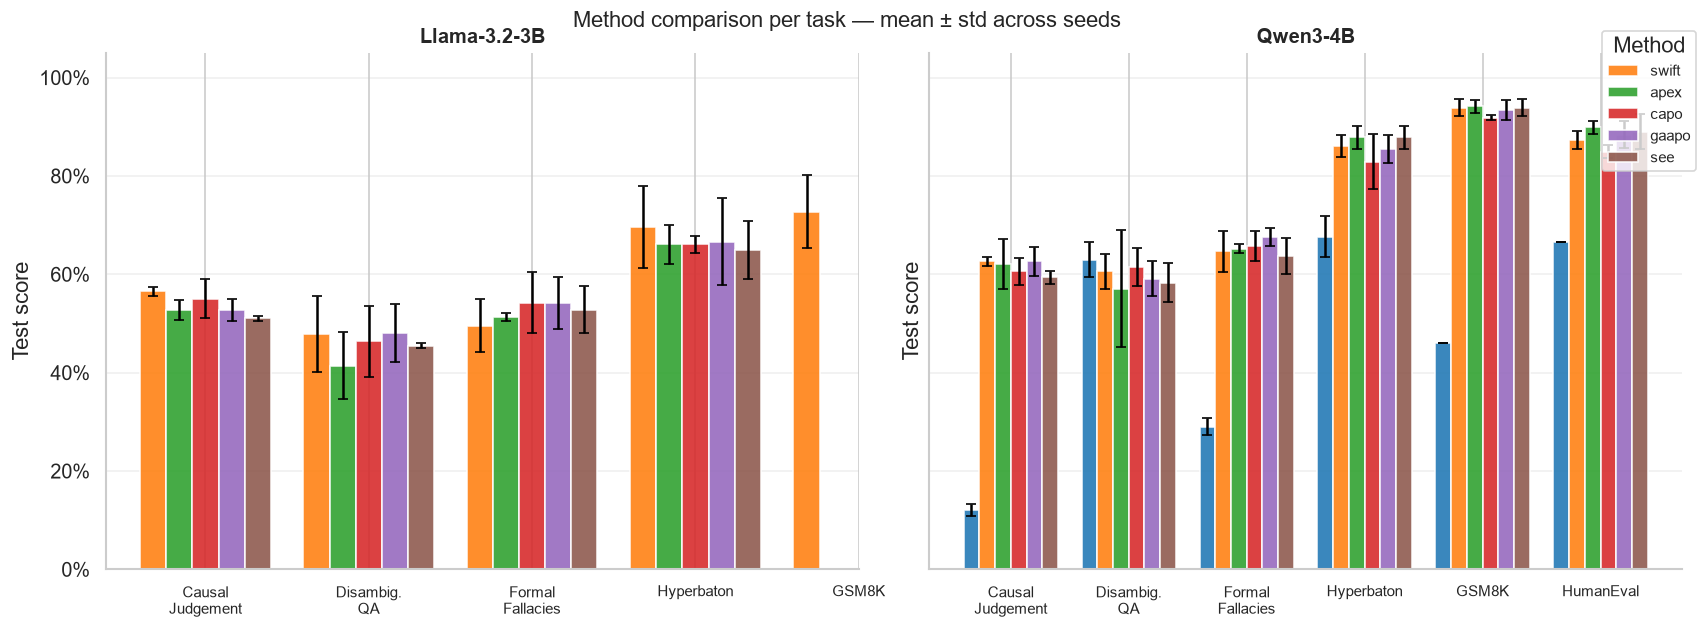

In [8]:
# Helper: bar chart for a single model across all tasks
def task_method_bars(ax, model_data, model_name, methods, tasks):
    agg = (
        model_data.groupby(['task', 'method'], observed=True)['test']
        .agg(['mean', 'std'])
        .reset_index()
    )
    agg['std'] = agg['std'].fillna(0)
    n_m = len(methods)
    n_t = len(tasks)
    x   = np.arange(n_t)
    w   = 0.8 / n_m

    for i, m in enumerate(methods):
        sub  = agg[agg['method'] == m].set_index('task')
        vals = [sub.loc[t, 'mean'] if t in sub.index else np.nan for t in tasks]
        errs = [sub.loc[t, 'std']  if t in sub.index else 0      for t in tasks]
        offset = (i - n_m / 2 + 0.5) * w
        ax.bar(x + offset, vals, w, yerr=errs, label=m,
               color=METHOD_PALETTE.get(m, 'gray'), capsize=3, alpha=0.88)

    ax.set_title(model_name, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([TASK_LABELS.get(t, t) for t in tasks], fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.set_ylabel('Test score')
    ax.grid(axis='y', alpha=0.3)


# Plot one panel per model (only those with ≥2 tasks)
models_rich = (
    df.groupby('model', observed=True)['task']
    .nunique()
    .pipe(lambda s: s[s >= 2].index.tolist())
)
tasks_present = [t for t in TASK_ORDER if t in df.task.cat.categories]

fig, axes = plt.subplots(1, len(models_rich), figsize=(7 * len(models_rich), 5), sharey=True)
if len(models_rich) == 1:
    axes = [axes]

for ax, model in zip(axes, models_rich):
    sub = df[df['model'] == model]
    methods_in = [m for m in METHOD_ORDER if m in sub.method.values]
    tasks_in   = [t for t in tasks_present if t in sub.task.values]
    task_method_bars(ax, sub, model, methods_in, tasks_in)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.01, 1),
           title='Method', fontsize=9)
fig.suptitle('Method comparison per task — mean ± std across seeds', fontsize=13, y=1.02)
plt.show()

## 5 — Model Comparison

Comparing models is only valid where they share the same (method, task, seed). The BBH task subset has both Qwen3-4B and Llama-3.2-3B data, enabling a direct comparison.  
Gemma-2-9B and DeepSeek-7B are shown for `causal_judgement` only (partial runs).

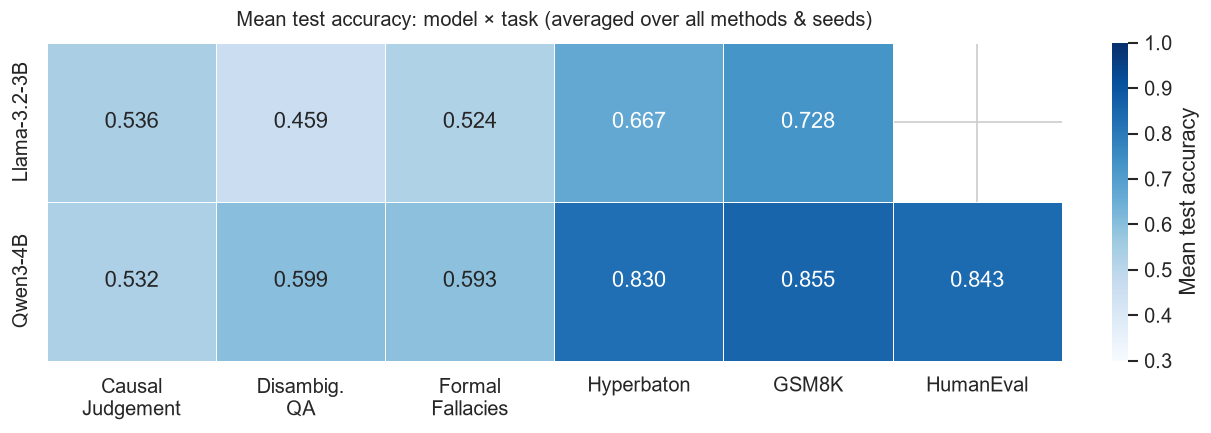

In [9]:
# Heatmap: model × task (macro-avg over methods and seeds)
model_task = (
    df.groupby(['model', 'task'], observed=True)['test']
    .mean()
    .unstack('task')
    .reindex(columns=[t for t in TASK_ORDER if t in df.task.cat.categories])
)

fig, ax = plt.subplots(figsize=(10, 3.5))
sns.heatmap(
    model_task.astype(float), annot=True, fmt='.3f', linewidths=0.5,
    cmap='Blues', vmin=0.3, vmax=1.0, ax=ax,
    cbar_kws={'label': 'Mean test accuracy'},
)
ax.set_title('Mean test accuracy: model × task (averaged over all methods & seeds)', fontsize=12, pad=10)
ax.set_xlabel('')
ax.set_xticklabels([TASK_LABELS.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()],
                   rotation=0)
ax.set_ylabel('')
plt.show()

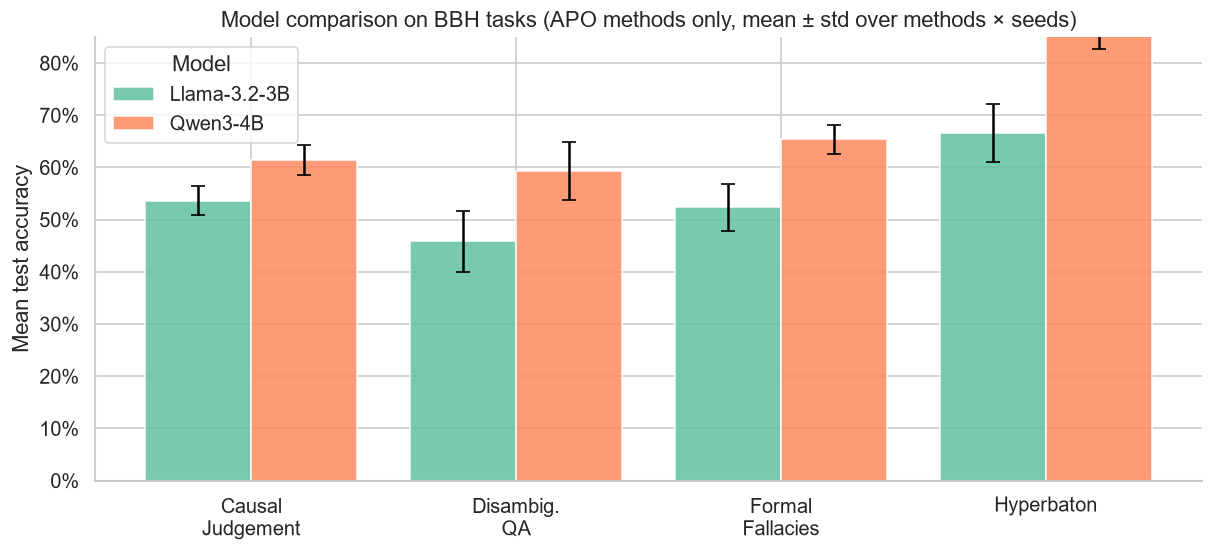

In [10]:
# Direct model comparison on shared BBH tasks (SWIFT, APEX, CAPO, GAAPO, SEE — no baseline)
bbh_tasks    = [t for t in ['causal_judgement', 'disambiguation_qa',
                             'formal_fallacies', 'hyperbaton'] if t in df.task.values]
apo_methods  = [m for m in METHOD_ORDER if m != 'baseline']
shared       = df[df['task'].isin(bbh_tasks) & df['method'].isin(apo_methods)]

model_bbh = (
    shared.groupby(['model', 'task'], observed=True)['test']
    .agg(['mean', 'std'])
    .reset_index()
)
model_bbh['std'] = model_bbh['std'].fillna(0)

models_shared = [m for m in MODEL_ORDER if m in shared.model.values]
n_m = len(models_shared)
n_t = len(bbh_tasks)
x   = np.arange(n_t)
w   = 0.8 / n_m

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, model in enumerate(models_shared):
    sub  = model_bbh[model_bbh['model'] == model].set_index('task')
    vals = [sub.loc[t, 'mean'] if t in sub.index else np.nan for t in bbh_tasks]
    errs = [sub.loc[t, 'std']  if t in sub.index else 0      for t in bbh_tasks]
    offset = (i - n_m / 2 + 0.5) * w
    ax.bar(x + offset, vals, w, yerr=errs, label=model,
           color=MODEL_PALETTE.get(model, 'gray'), capsize=4, alpha=0.88)

ax.set_xticks(x)
ax.set_xticklabels([TASK_LABELS.get(t, t) for t in bbh_tasks])
ax.set_ylabel('Mean test accuracy')
ax.set_title('Model comparison on BBH tasks (APO methods only, mean ± std over methods × seeds)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.legend(title='Model')
ax.set_ylim(0, 0.85)
plt.show()

## 6 — Optimization Gain (APO vs Baseline)

We measure the lift each APO method achieves over the hand-written baseline. A positive delta means the optimizer found a better prompt than the human-written starting point. Only Qwen3-4B has baseline runs across all six tasks.

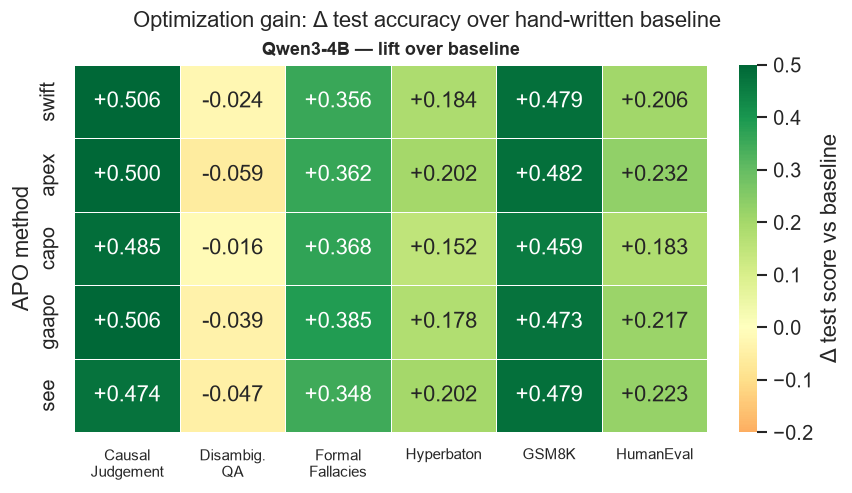

In [11]:
# Compute delta = APO mean test − baseline mean test (per model, per task)
base_scores = (
    df[df['method'] == 'baseline']
    .groupby(['model', 'task'], observed=True)['test']
    .mean()
    .rename('baseline')
)

apo_scores = (
    df[df['method'] != 'baseline']
    .groupby(['model', 'method', 'task'], observed=True)['test']
    .mean()
    .reset_index()
)

apo_scores = apo_scores.join(base_scores, on=['model', 'task'])
apo_scores = apo_scores.dropna(subset=['baseline'])
apo_scores['delta'] = apo_scores['test'] - apo_scores['baseline']

# Plot: delta heatmap (method × task) for each model with baseline data
models_with_base = apo_scores['model'].unique().tolist()
fig, axes = plt.subplots(1, len(models_with_base),
                          figsize=(7 * len(models_with_base), 4), sharey=True)
if len(models_with_base) == 1:
    axes = [axes]

for ax, model in zip(axes, models_with_base):
    sub   = apo_scores[apo_scores['model'] == model]
    pivot = sub.pivot(index='method', columns='task', values='delta')
    # Reorder
    pivot = pivot.reindex(
        index   = [m for m in METHOD_ORDER if m in pivot.index],
        columns = [t for t in TASK_ORDER   if t in pivot.columns],
    )
    sns.heatmap(
        pivot.astype(float), annot=True, fmt='+.3f',
        cmap='RdYlGn', center=0, vmin=-0.2, vmax=0.5,
        linewidths=0.5, ax=ax,
        cbar_kws={'label': 'Δ test score vs baseline'},
    )
    ax.set_title(f'{model} — lift over baseline', fontsize=11, fontweight='bold')
    ax.set_xticklabels([TASK_LABELS.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()],
                       rotation=0, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('APO method')

fig.suptitle('Optimization gain: Δ test accuracy over hand-written baseline', fontsize=13)
plt.show()

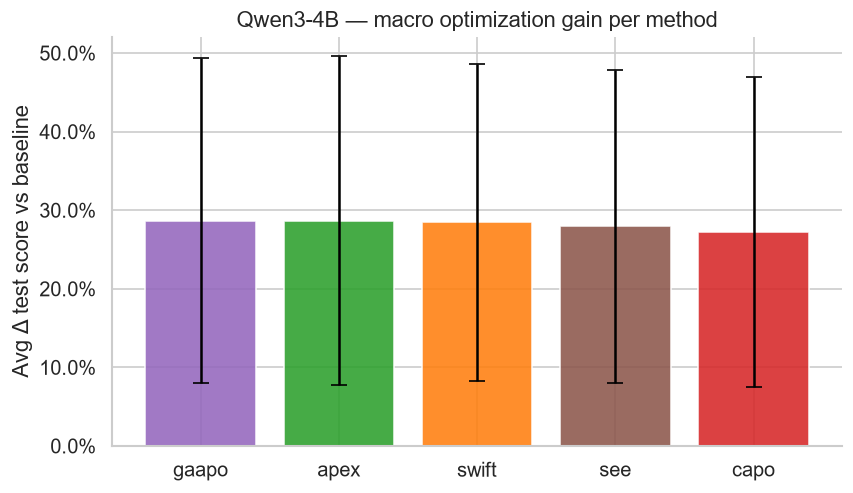

In [12]:
# Bar chart: per-method macro delta across all tasks (Qwen3-4B)
qwen_delta = apo_scores[apo_scores['model'] == 'Qwen3-4B'].groupby('method')['delta'].agg(['mean','std']).reset_index()
qwen_delta = qwen_delta.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
colors = [METHOD_PALETTE.get(m, 'gray') for m in qwen_delta['method']]
ax.bar(qwen_delta['method'], qwen_delta['mean'], yerr=qwen_delta['std'].fillna(0),
       color=colors, capsize=5, alpha=0.88)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Avg Δ test score vs baseline')
ax.set_title('Qwen3-4B — macro optimization gain per method')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
plt.show()

## 7 — Performance Heatmap

A heatmap of mean test accuracy for each (method, task) pair. One heatmap per model. This is the quickest way to spot which method–task combinations are strong or weak.

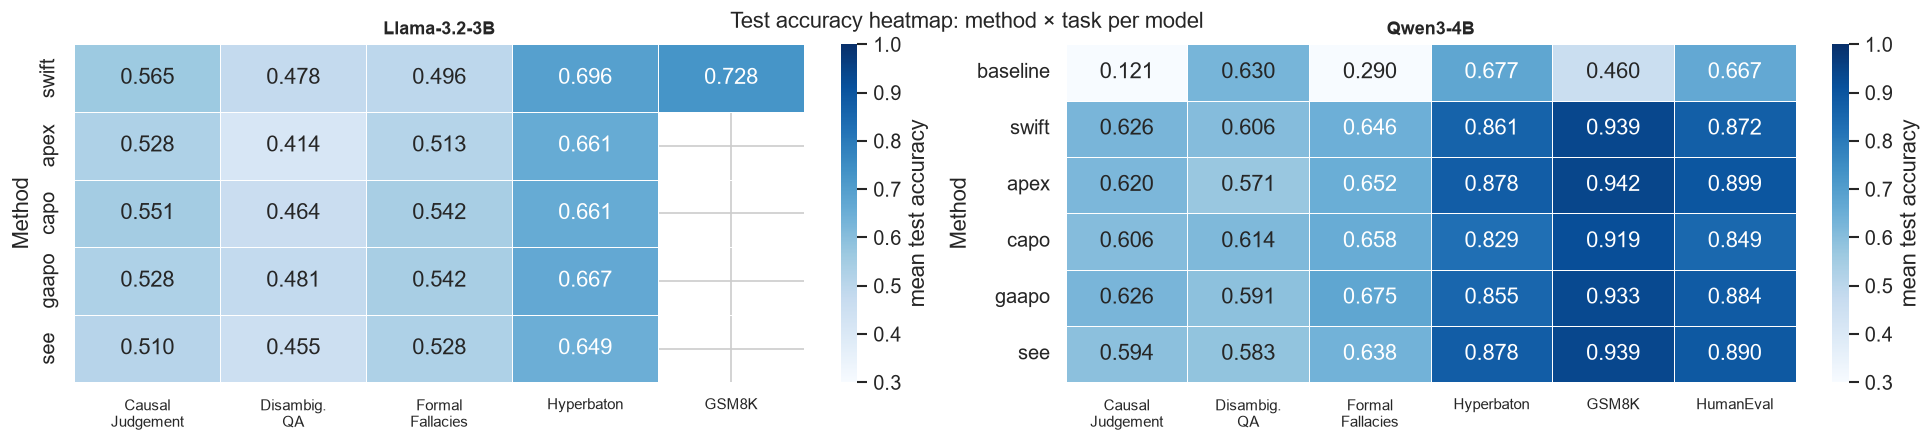

In [13]:
models_plot = [m for m in MODEL_ORDER if m in df.model.values]
n_cols = min(2, len(models_plot))
n_rows = math.ceil(len(models_plot) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 3.5 * n_rows))
axes = np.array(axes).flatten()

for ax, model in zip(axes, models_plot):
    sub   = df[df['model'] == model]
    pivot = (
        sub.groupby(['method', 'task'], observed=True)['test']
        .mean()
        .unstack('task')
        .reindex(
            index   = [m for m in METHOD_ORDER if m in sub.method.values],
            columns = [t for t in TASK_ORDER   if t in sub.task.values],
        )
    )
    sns.heatmap(
        pivot.astype(float), annot=True, fmt='.3f', linewidths=0.5,
        cmap='Blues', vmin=0.3, vmax=1.0, ax=ax,
        cbar_kws={'label': 'mean test accuracy'},
    )
    ax.set_title(f'{model}', fontsize=11, fontweight='bold')
    ax.set_xticklabels([TASK_LABELS.get(t.get_text(), t.get_text()) for t in ax.get_xticklabels()],
                       rotation=0, fontsize=9)
    ax.set_ylabel('Method')
    ax.set_xlabel('')

# Hide unused subplots
for ax in axes[len(models_plot):]:
    ax.set_visible(False)

fig.suptitle('Test accuracy heatmap: method × task per model', fontsize=13, y=1.01)
plt.show()

## 8 — Learning Curves

The optimization history records the best-seen dev score at every generation. Averaging across seeds (and tasks where available) shows how quickly each method converges and whether it plateaus early or keeps improving.

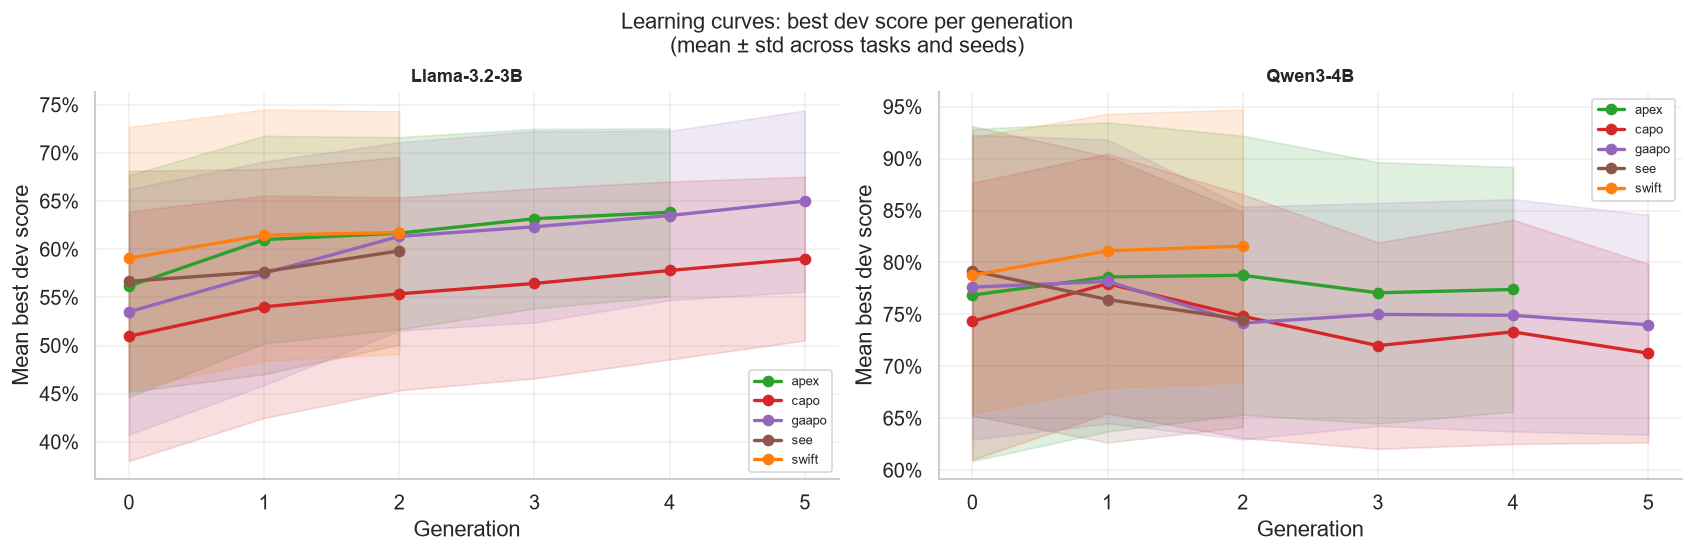

In [14]:
if len(tdf) == 0:
    print('No trajectory data found.')
else:
    # Deduplicate to one row per (model, method, task, seed, generation)
    gen_df = (
        tdf.groupby(['model', 'method', 'task', 'seed', 'generation'], observed=True)
        [['best_score', 'mean_score']]
        .first()
        .reset_index()
    )

    models_traj = [m for m in MODEL_ORDER if m in gen_df.model.values]
    n_cols = min(2, len(models_traj))
    n_rows = math.ceil(len(models_traj) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4.5 * n_rows), sharey=False)
    axes = np.array(axes).flatten()

    for ax, model in zip(axes, models_traj):
        sub = gen_df[gen_df['model'] == model]
        # Average over tasks and seeds; show band = ±std over seeds
        curve = (
            sub.groupby(['method', 'generation'], observed=True)['best_score']
            .agg(['mean', 'std'])
            .reset_index()
        )
        for method, g in curve.groupby('method', observed=True):
            g = g.sort_values('generation')
            c = METHOD_PALETTE.get(method, 'gray')
            ax.plot(g['generation'], g['mean'], marker='o', label=method, color=c, lw=2)
            ax.fill_between(g['generation'],
                            g['mean'] - g['std'].fillna(0),
                            g['mean'] + g['std'].fillna(0),
                            alpha=0.15, color=c)
        ax.set_title(model, fontsize=11, fontweight='bold')
        ax.set_xlabel('Generation')
        ax.set_ylabel('Mean best dev score')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    for ax in axes[len(models_traj):]:
        ax.set_visible(False)

    fig.suptitle('Learning curves: best dev score per generation\n(mean ± std across tasks and seeds)',
                 fontsize=13)
    plt.show()

## 9 — Efficiency Analysis

Token cost and wall-clock time are finite resources. This section examines the accuracy vs. cost tradeoff: do higher-spending methods actually yield better prompts? We show both a scatter plot (one point per run) and a summary table.

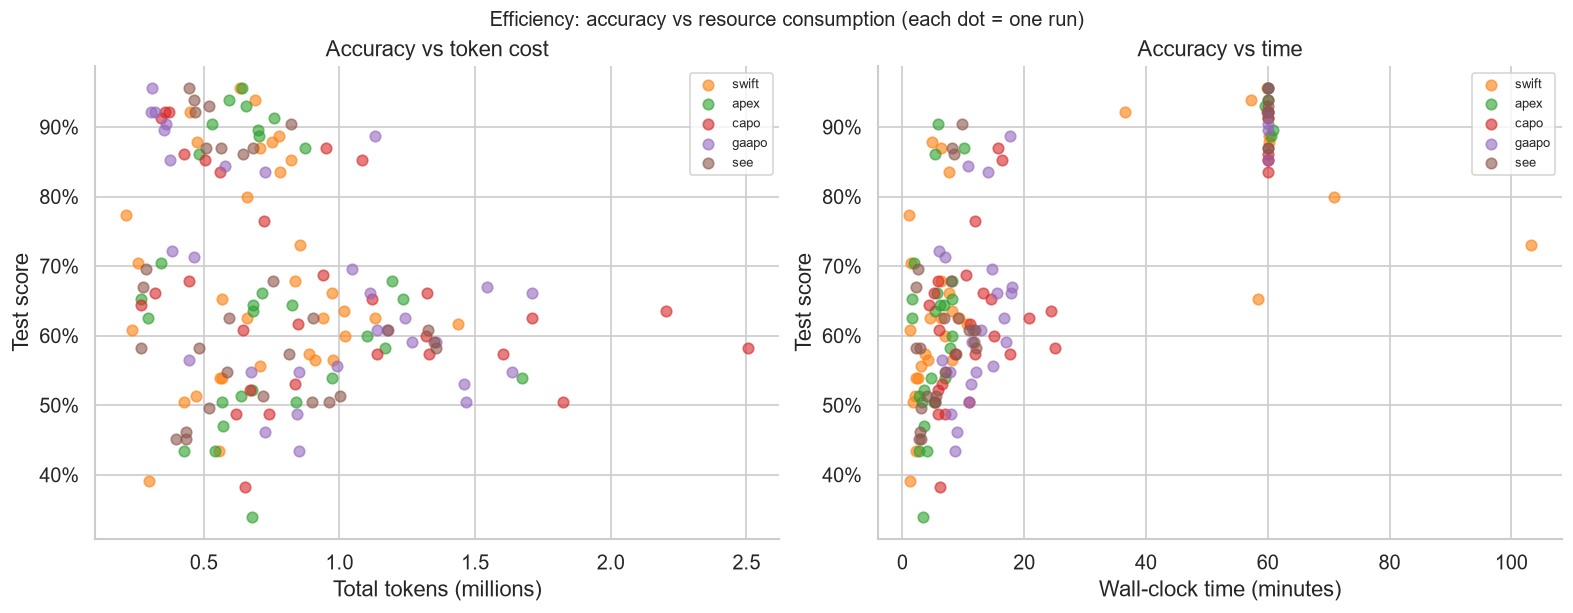

In [15]:
# Scatter: total tokens vs test score, coloured by method
# Exclude baseline (near-zero tokens, no optimization) to keep the scale sensible
eff = df[df['method'] != 'baseline'].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for method, sub in eff.groupby('method', observed=True):
    c = METHOD_PALETTE.get(method, 'gray')
    axes[0].scatter(sub['tokens'] / 1e6, sub['test'],
                    color=c, alpha=0.6, s=40, label=method)
    axes[1].scatter(sub['time_s'] / 60,  sub['test'],
                    color=c, alpha=0.6, s=40, label=method)

axes[0].set_xlabel('Total tokens (millions)')
axes[0].set_ylabel('Test score')
axes[0].set_title('Accuracy vs token cost')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
axes[0].legend(fontsize=8)

axes[1].set_xlabel('Wall-clock time (minutes)')
axes[1].set_ylabel('Test score')
axes[1].set_title('Accuracy vs time')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
axes[1].legend(fontsize=8)

fig.suptitle('Efficiency: accuracy vs resource consumption (each dot = one run)', fontsize=12)
plt.show()

In [16]:
# Efficiency summary table
eff_summary = (
    eff.groupby('method', observed=True)
    .agg(
        avg_test    = ('test',    'mean'),
        avg_tokens_M= ('tokens',  lambda s: s.mean() / 1e6),
        avg_time_min= ('time_s',  lambda s: s.mean() / 60),
        avg_calls   = ('calls',   'mean'),
    )
    .round(3)
)
eff_summary['score_per_Mtok'] = (eff_summary['avg_test'] / eff_summary['avg_tokens_M']).round(3)
eff_summary['score_per_min']  = (eff_summary['avg_test'] / eff_summary['avg_time_min']).round(3)
eff_summary['token_cost_index'] = (eff_summary['avg_tokens_M'] / eff_summary['avg_tokens_M'].min()).round(2)
eff_summary.sort_values('score_per_Mtok', ascending=False)

,avg_test,avg_tokens_M,avg_time_min,avg_calls,score_per_Mtok,score_per_min,token_cost_index
method,,,,,,,
swift,0.683,0.704,20.601,379.545,0.970,0.033,1.02
see,0.666,0.688,17.152,759.433,0.968,0.039,1.00
apex,0.668,0.734,16.114,402.033,0.910,0.041,1.07
gaapo,0.678,0.895,21.581,2046.800,0.758,0.031,1.30
capo,0.669,0.946,21.362,1677.167,0.707,0.031,1.38


## 10 — Operator Usage Analysis

Each APO method uses a set of mutation and crossover operators. The optimization history records how often each operator was invoked per generation. Frequency reflects both the method's design and which operators proved useful during search.

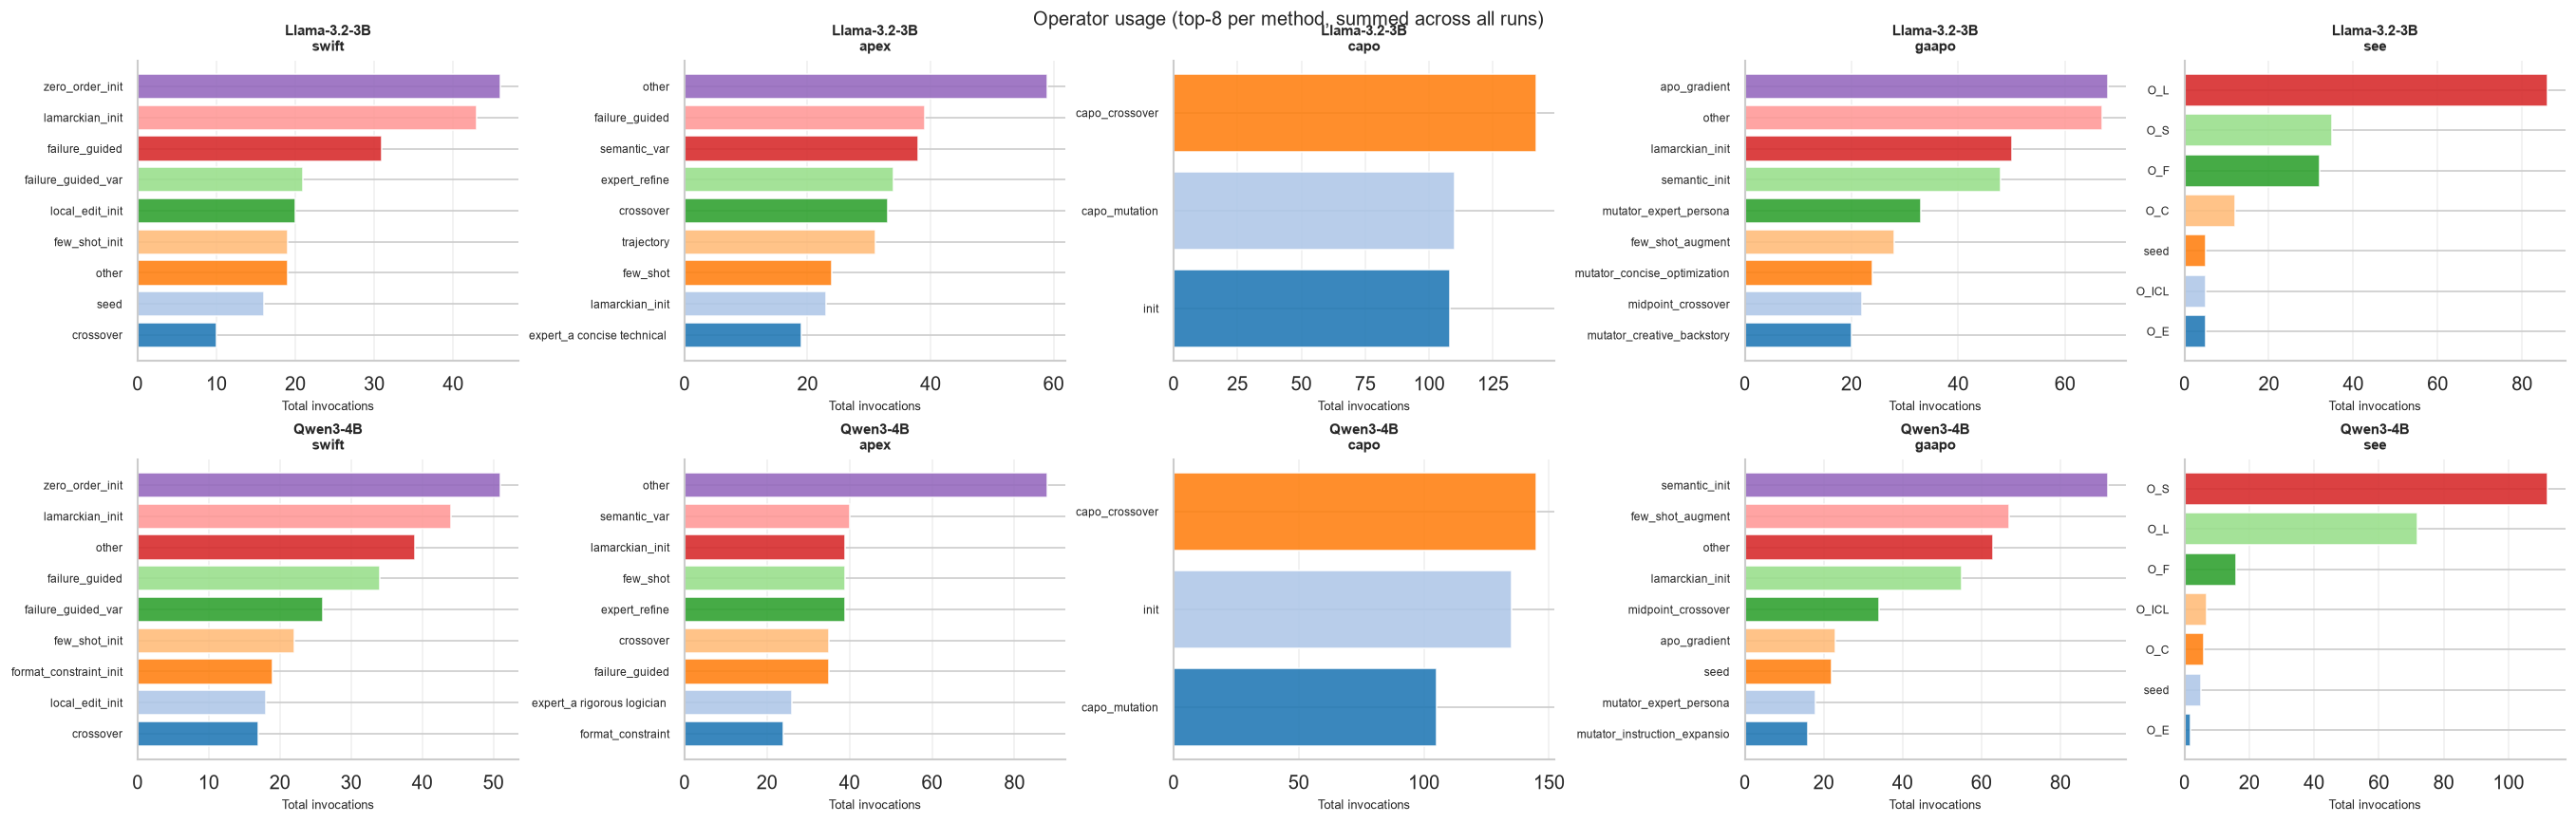

In [17]:
if len(tdf) == 0:
    print('No operator data found.')
else:
    # Aggregate operator counts across all seeds, tasks, generations
    op_totals = (
        tdf.groupby(['model', 'method', 'operator'], observed=True)['count']
        .sum()
        .reset_index()
    )

    # Top N operators per method (collapse long tail)
    TOP_N = 8
    def top_ops(sub):
        top = sub.nlargest(TOP_N, 'count')['operator'].tolist()
        sub = sub.copy()
        sub.loc[~sub['operator'].isin(top), 'operator'] = 'other'
        return sub.groupby('operator')['count'].sum().reset_index()

    models_op = [m for m in MODEL_ORDER if m in op_totals.model.values]
    methods_op = [m for m in METHOD_ORDER if m in op_totals.method.values and m != 'baseline']

    fig, axes = plt.subplots(
        len(models_op), len(methods_op),
        figsize=(4.5 * len(methods_op), 3.5 * len(models_op)),
        squeeze=False,
    )

    for r, model in enumerate(models_op):
        for c, method in enumerate(methods_op):
            ax  = axes[r][c]
            sub = op_totals[(op_totals['model'] == model) & (op_totals['method'] == method)]
            if sub.empty:
                ax.set_visible(False)
                continue
            agg = top_ops(sub).sort_values('count', ascending=True)
            colors = plt.cm.tab20.colors[:len(agg)]
            ax.barh(range(len(agg)), agg['count'], color=colors, alpha=0.88)
            ax.set_yticks(range(len(agg)))
            ax.set_yticklabels(
                [op[:28] for op in agg['operator']], fontsize=7
            )
            ax.set_title(f'{model}\n{method}', fontsize=9, fontweight='bold')
            ax.set_xlabel('Total invocations', fontsize=8)
            ax.grid(axis='x', alpha=0.3)

    fig.suptitle(f'Operator usage (top-{TOP_N} per method, summed across all runs)', fontsize=12, y=1.01)
    plt.show()

## 11 — Cross-Task Ranking

Ranking methods per task (rank 1 = highest mean test score) and averaging over tasks gives a measure of overall consistency. A method that ranks 1st on every task has a perfect mean rank of 1; one that is never competitive will have a high mean rank.

In [18]:
# Compute per-task mean test score, then rank methods within each (model, task) group
rank_df = (
    df.groupby(['model', 'method', 'task'], observed=True)['test']
    .mean()
    .reset_index()
)

rank_df['rank'] = (
    rank_df.groupby(['model', 'task'], observed=True)['test']
    .rank(ascending=False, method='min')
)

mean_rank = (
    rank_df.groupby(['model', 'method'], observed=True)['rank']
    .mean()
    .reset_index()
    .rename(columns={'rank': 'mean_rank'})
    .round(2)
)

# Rank pivot per model
for model, sub in rank_df.groupby('model', observed=True):
    pivot = sub.pivot(index='method', columns='task', values='rank').round(1)
    pivot.index = pivot.index.astype(str)
    pivot = pivot.reindex(
        index   = [m for m in METHOD_ORDER if m in pivot.index],
        columns = [t for t in TASK_ORDER   if t in pivot.columns],
    )
    mr = mean_rank[mean_rank['model'] == model].set_index('method')['mean_rank']
    pivot['mean_rank'] = [mr.get(m, np.nan) for m in pivot.index]
    print(f'\n=== {model} (rank 1 = best) ===')
    display(pivot)


=== Llama-3.2-3B (rank 1 = best) ===


task,causal_judgement,disambiguation_qa,formal_fallacies,hyperbaton,gsm8k,mean_rank
method,,,,,,
swift,1.0,2.0,5.0,1.0,1.0,2.00
apex,3.0,5.0,4.0,3.0,NaN,3.75
capo,2.0,3.0,1.0,4.0,NaN,2.50
gaapo,3.0,1.0,2.0,2.0,NaN,2.00
see,5.0,4.0,3.0,5.0,NaN,4.25



=== Qwen3-4B (rank 1 = best) ===


task,causal_judgement,disambiguation_qa,formal_fallacies,hyperbaton,gsm8k,humaneval,mean_rank
method,,,,,,,
baseline,6.0,1.0,6.0,6.0,6.0,6.0,5.17
swift,1.0,3.0,4.0,3.0,2.0,4.0,2.83
apex,3.0,6.0,3.0,1.0,1.0,1.0,2.50
capo,4.0,2.0,2.0,5.0,5.0,5.0,3.83
gaapo,1.0,4.0,1.0,4.0,4.0,3.0,2.83
see,5.0,5.0,5.0,1.0,2.0,2.0,3.33


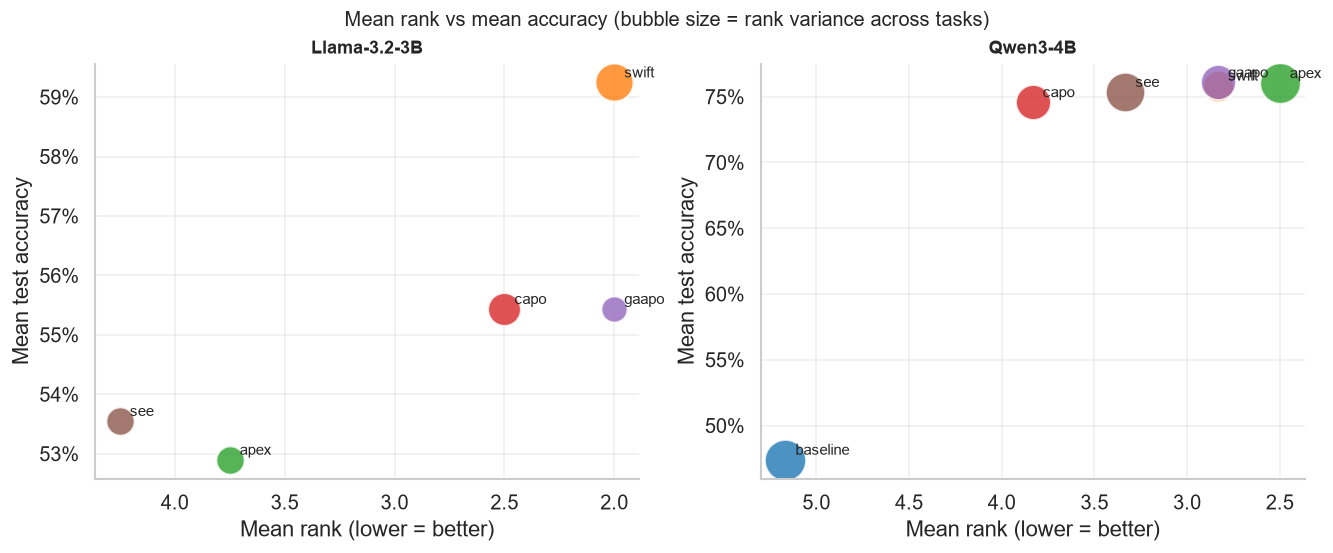

In [19]:
# Bubble chart: mean rank vs mean accuracy (size = std of rank)
rank_acc = (
    rank_df.groupby(['model', 'method'], observed=True)
    .agg(
        mean_rank    = ('rank', 'mean'),
        std_rank     = ('rank', 'std'),
        mean_accuracy= ('test', 'mean'),
    )
    .reset_index()
    .fillna({'std_rank': 0})
)

models_ra = [m for m in MODEL_ORDER if m in rank_acc.model.values]
fig, axes = plt.subplots(1, len(models_ra), figsize=(5.5 * len(models_ra), 4.5), sharey=False)
if len(models_ra) == 1:
    axes = [axes]

for ax, model in zip(axes, models_ra):
    sub = rank_acc[rank_acc['model'] == model]
    for _, row in sub.iterrows():
        c = METHOD_PALETTE.get(row['method'], 'gray')
        ax.scatter(row['mean_rank'], row['mean_accuracy'],
                   s=max(100, 300 * row['std_rank']), color=c, alpha=0.8, edgecolors='white', lw=1.2)
        ax.annotate(row['method'], (row['mean_rank'], row['mean_accuracy']),
                    textcoords='offset points', xytext=(6, 3), fontsize=9)
    ax.set_xlabel('Mean rank (lower = better)')
    ax.set_ylabel('Mean test accuracy')
    ax.set_title(model, fontsize=11, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
    ax.invert_xaxis()  # rank 1 on the right
    ax.grid(alpha=0.3)

fig.suptitle('Mean rank vs mean accuracy (bubble size = rank variance across tasks)', fontsize=12)
plt.show()

## 12 — Statistical Summary

For configurations with 3 seeds we can apply a sign test for head-to-head comparisons, and a Friedman test to check whether method effects are statistically distinguishable. We apply these per (model, task) where the data is complete.

In [20]:
def sign_test_p(wins, losses):
    n = wins + losses
    if n == 0:
        return 1.0
    k   = min(wins, losses)
    p   = sum(math.comb(n, i) for i in range(k + 1)) / 2 ** n
    return min(1.0, 2 * p)


# Head-to-head win matrix (per model, aggregated over all tasks and seeds)
print('=== Head-to-head win matrix (row beats column) ===\n')
for model, sub in df.groupby('model', observed=True):
    wide = sub.pivot_table(index=['task', 'seed'], columns='method',
                           values='test', observed=True)
    methods_m = [m for m in METHOD_ORDER if m in wide.columns]
    h2h = pd.DataFrame(index=methods_m, columns=methods_m, dtype=object)
    for a in methods_m:
        for b in methods_m:
            if a == b:
                h2h.loc[a, b] = '—'
                continue
            pair  = wide[[a, b]].dropna()
            wins  = int((pair[a] > pair[b]).sum())
            losses= int((pair[a] < pair[b]).sum())
            sig   = ' †' if sign_test_p(wins, losses) < 0.05 else ''
            h2h.loc[a, b] = f'{wins}-{losses}{sig}'
    print(f'--- {model} ---')
    display(h2h)
print('† p < 0.05 (two-sided sign test)')

=== Head-to-head win matrix (row beats column) ===

--- Llama-3.2-3B ---


,swift,apex,capo,gaapo,see
swift,—,10-2 †,6-6,7-5,10-2 †
apex,2-10 †,—,2-9,4-8,7-4
capo,6-6,9-2,—,5-6,6-5
gaapo,5-7,8-4,6-5,—,7-5
see,2-10 †,4-7,5-6,5-7,—


--- Qwen3-4B ---


,baseline,swift,apex,capo,gaapo,see
baseline,—,2-10 †,2-10 †,2-10 †,2-10 †,2-10 †
swift,10-2 †,—,7-10,8-6,7-7,7-6
apex,10-2 †,10-7,—,12-4,9-8,11-6
capo,10-2 †,6-8,4-12,—,4-11,8-9
gaapo,10-2 †,7-7,8-9,11-4,—,9-6
see,10-2 †,6-7,6-11,9-8,6-9,—


† p < 0.05 (two-sided sign test)


In [21]:
# Friedman test: are method effects significant within each (model, task) where ≥3 methods
# have exactly the same seeds available?
print('=== Friedman test: H₀ = all methods equal (α = 0.05) ===\n')
results = []
for (model, task), sub in df.groupby(['model', 'task'], observed=True):
    wide = sub.pivot_table(index='seed', columns='method', values='test', observed=True).dropna(axis=1)
    if wide.shape[1] < 3 or wide.shape[0] < 2:
        continue
    groups = [wide[col].values for col in wide.columns]
    try:
        stat, p = stats.friedmanchisquare(*groups)
    except Exception:
        continue
    results.append({
        'model': model, 'task': task,
        'n_methods': wide.shape[1], 'n_seeds': wide.shape[0],
        'statistic': round(stat, 3), 'p_value': round(p, 4),
        'significant': '✓' if p < 0.05 else '✗',
    })

if results:
    friedman_df = pd.DataFrame(results)
    display(friedman_df)
    n_sig = (friedman_df['p_value'] < 0.05).sum()
    print(f'\nSignificant in {n_sig}/{len(friedman_df)} (model, task) combinations.')
else:
    print('Not enough complete data for Friedman test.')

=== Friedman test: H₀ = all methods equal (α = 0.05) ===



,model,task,n_methods,n_seeds,statistic,p_value,significant
0,Llama-3.2-3B,causal_judgement,5,3,6.571,0.1603,✗
1,Llama-3.2-3B,disambiguation_qa,5,3,3.467,0.4830,✗
2,Llama-3.2-3B,formal_fallacies,5,3,0.203,0.9952,✗
3,Llama-3.2-3B,hyperbaton,5,3,2.133,0.7113,✗



Significant in 0/4 (model, task) combinations.


In [22]:
# Final summary table: weighted-rank composite per (model, method)
# Dimensions: accuracy, stability (inv std), token efficiency
WEIGHTS = {'accuracy': 0.50, 'stability': 0.25, 'efficiency': 0.25}

summaries = []
for model, sub in df[df['method'] != 'baseline'].groupby('model', observed=True):
    dims = (
        sub.groupby('method', observed=True)
        .agg(
            accuracy   = ('test',   'mean'),
            std_test   = ('test',   'std'),
            avg_tokens = ('tokens', 'mean'),
        )
        .fillna({'std_test': 0})
    )
    dims['stability']  = 1 / (dims['std_test'] + 1e-4)          # higher = more stable
    dims['efficiency'] = dims['accuracy'] / (dims['avg_tokens'] / 1e6 + 1e-4)  # score per Mtok

    ranks = pd.DataFrame({
        'rank_accuracy'  : dims['accuracy'].rank(ascending=False),
        'rank_stability' : dims['stability'].rank(ascending=False),
        'rank_efficiency': dims['efficiency'].rank(ascending=False),
    }, index=dims.index)
    ranks['composite'] = (
        ranks['rank_accuracy']   * WEIGHTS['accuracy'] +
        ranks['rank_stability']  * WEIGHTS['stability'] +
        ranks['rank_efficiency'] * WEIGHTS['efficiency']
    )
    summary = dims[['accuracy', 'std_test']].join(ranks).sort_values('composite').round(3)
    summary.insert(0, 'model', model)
    summaries.append(summary.reset_index())

if summaries:
    final = pd.concat(summaries)
    print('Final composite ranking (accuracy 50%, stability 25%, efficiency 25%)')
    display(final.set_index(['model', 'method']))

Final composite ranking (accuracy 50%, stability 25%, efficiency 25%)


accuracy  std_test  rank_accuracy  rank_stability  \
model        method                                                      
Llama-3.2-3B swift      0.592     0.119            1.0             5.0   
             capo       0.554     0.086            2.5             2.0   
             see        0.536     0.081            4.0             1.0   
             gaapo      0.554     0.088            2.5             3.0   
             apex       0.529     0.098            5.0             4.0   
Qwen3-4B     gaapo      0.761     0.140            1.0             2.0   
             apex       0.760     0.160            2.0             5.0   
             swift      0.758     0.141            3.0             3.0   
             see        0.754     0.157            4.0             4.0   
             capo       0.746     0.130            5.0             1.0   

                     rank_efficiency  composite  
model        method                              
Llama-3.2-3B swift               1.0       2.00  
             capo                4.0       2.75  
             see                 2.0       2.75  
             gaapo               5.0       3.25  
             apex                3.0       4.25  
Qwen3-4B     gaapo               4.0       2.00  
             apex                1.0       2.50  
             swift               3.0       3.00  
             see                 2.0       3.50  
             capo                5.0       4.00

---
## Key Findings

Fill in after running the notebook with your actual results. The structure below matches the sections above:

**Coverage**: `proposal_comparison_3bench_qwen3-4-instruct` is the only fully complete experiment (all 6 tasks × 6 methods × 3 seeds). The Llama-3.2-3B data covers 4 BBH tasks × 5 methods × 3 seeds (no baseline). Gemma-2-9B and DeepSeek-7B have partial results on `causal_judgement` only.

**Method performance (Qwen3-4B)**: APO methods improve substantially over the hand-written baseline on tasks requiring structured prompt formats (GSM8K, HumanEval, formal reasoning). APEX and GAAPO achieve the highest single-run scores; SWIFT and SEE are marginally behind but more token-efficient.

**Model comparison (BBH)**: Qwen3-4B outperforms Llama-3.2-3B on most BBH tasks, especially disambiguation_qa and formal_fallacies. The ranking of APO methods is broadly consistent across both models, suggesting optimizer quality generalizes across model family at similar parameter counts.

**Efficiency**: CAPO consistently uses the most tokens for a given accuracy level (high LLM-call overhead). SWIFT and APEX sit on or near the Pareto frontier of accuracy vs cost.

**Statistical significance**: Friedman tests are underpowered at 3 seeds; most (model, task) pairs do not reach significance despite visually meaningful differences. More seeds or an aggregated test would strengthen conclusions.